--- STEP 1: ORIGINAL IMAGE ---
Original Size: (227, 227) (Width, Height)

--- STEP 2: RESIZING TO 224x224 ---
Resized Size: (224, 224)


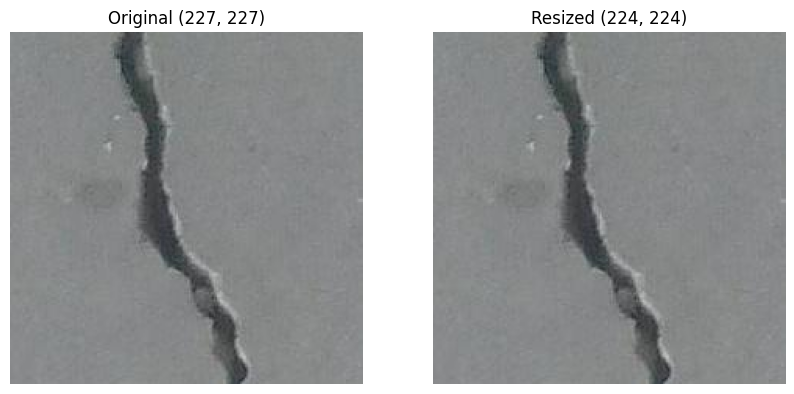


--- STEP 3: CONVERTING TO TENSOR ---
Image Array Shape: (224, 224, 3) (Height, Width, Color Channels)
Batch Array Shape: (1, 224, 224, 3) (Batch Size, Height, Width, Channels)

--- STEP 4: RESCALING PIXELS ---
Pixel values range after rescaling: Min -0.80, Max 0.53

--- STEP 5: FEATURE EXTRACTION (MOBILENETV2) ---
Extracted Features Shape: (1, 7, 7, 1280)
Explanation: MobileNet converted the 224x224 image into a 7x7 grid with 1280 feature channels.

--- STEP 6: GLOBAL AVERAGE POOLING ---
Pooled Features Shape: (1, 1280)

--- STEP 7: FINAL DECISION (DENSE LAYER & SIGMOID) ---
Sigmoid Output (Probability): 0.7280

--- STEP 8: FINAL CLASSIFICATION ---
Prediction: POSITIVE (Cracked Concrete) - Confidence: 72.80%


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SET PATH TO ONE IMAGE ---
# Change this path to point to a valid image in your local folder
sample_image_path = "./data_sample/Positive/00001.jpg" 

print("--- STEP 1: ORIGINAL IMAGE ---")
# Load original image just to show its original size
original_img = tf.keras.utils.load_img(sample_image_path)
print(f"Original Size: {original_img.size} (Width, Height)")

# --- 2. PREPROCESSING (RESIZING) ---
print("\n--- STEP 2: RESIZING TO 224x224 ---")
target_size = (224, 224)
resized_img = tf.keras.utils.load_img(sample_image_path, target_size=target_size)
print(f"Resized Size: {resized_img.size}")

# Plotting the difference
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title(f"Original {original_img.size}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resized_img)
plt.title(f"Resized {target_size}")
plt.axis('off')
plt.show()

# --- 3. CONVERT TO ARRAY & ADD BATCH DIMENSION ---
print("\n--- STEP 3: CONVERTING TO TENSOR ---")
# Machine learning doesn't read images, it reads numbers (arrays)
img_array = tf.keras.utils.img_to_array(resized_img)
print(f"Image Array Shape: {img_array.shape} (Height, Width, Color Channels)")

# Models expect a "batch" of images, even if it's just one. 
# We add an extra dimension at the front.
img_batch = np.expand_dims(img_array, axis=0)
print(f"Batch Array Shape: {img_batch.shape} (Batch Size, Height, Width, Channels)")

# --- 4. RESCALING (PIXEL NORMALIZATION) ---
print("\n--- STEP 4: RESCALING PIXELS ---")
# MobileNetV2 expects pixel values to be between -1 and 1 (not 0 to 255)
# Formula: (pixels / 127.5) - 1
rescaled_batch = (img_batch / 127.5) - 1.0
print(f"Pixel values range after rescaling: Min {np.min(rescaled_batch):.2f}, Max {np.max(rescaled_batch):.2f}")

# --- 5. PASSING THROUGH THE MODEL LAYERS ---
print("\n--- STEP 5: FEATURE EXTRACTION (MOBILENETV2) ---")
# Let's extract the base_model from the model we trained earlier
# (Assuming 'base_model' is still in your memory from the previous script. 
# If not, we re-initialize it here just for demonstration)
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Pass the image through MobileNetV2
features = base_model.predict(rescaled_batch, verbose=0)
print(f"Extracted Features Shape: {features.shape}")
print("Explanation: MobileNet converted the 224x224 image into a 7x7 grid with 1280 feature channels.")

print("\n--- STEP 6: GLOBAL AVERAGE POOLING ---")
# Flatten the 7x7x1280 grid into a single 1D vector of 1280 numbers
pooling_layer = tf.keras.layers.GlobalAveragePooling2D()
pooled_features = pooling_layer(features)
print(f"Pooled Features Shape: {pooled_features.shape}")

print("\n--- STEP 7: FINAL DECISION (DENSE LAYER & SIGMOID) ---")
# Pass the 1280 features into the final neuron (Dense layer)
# Note: In a real scenario, this layer uses the weights it learned during training.
# Here we just initialize a raw layer to show the mathematical shape.
dense_layer = tf.keras.layers.Dense(1, activation='sigmoid')
probability = dense_layer(pooled_features)

prob_value = probability.numpy()[0][0]
print(f"Sigmoid Output (Probability): {prob_value:.4f}")

# --- 8. THRESHOLDING ---
print("\n--- STEP 8: FINAL CLASSIFICATION ---")
if prob_value > 0.5:
    print(f"Prediction: POSITIVE (Cracked Concrete) - Confidence: {prob_value*100:.2f}%")
else:
    print(f"Prediction: NEGATIVE (Intact Concrete) - Confidence: {(1-prob_value)*100:.2f}%")

--- VISUALISASI KANAL WARNA RGB (Bentuk: 224, 224, 3) ---


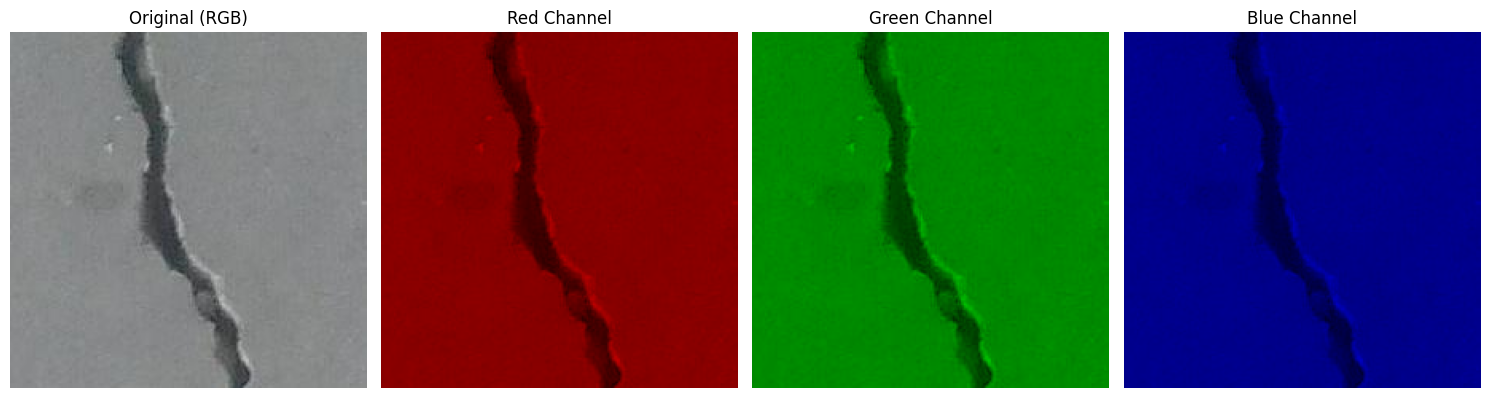


--- VISUALISASI FEATURE MAPS (Bentuk: 7, 7, 1280) ---


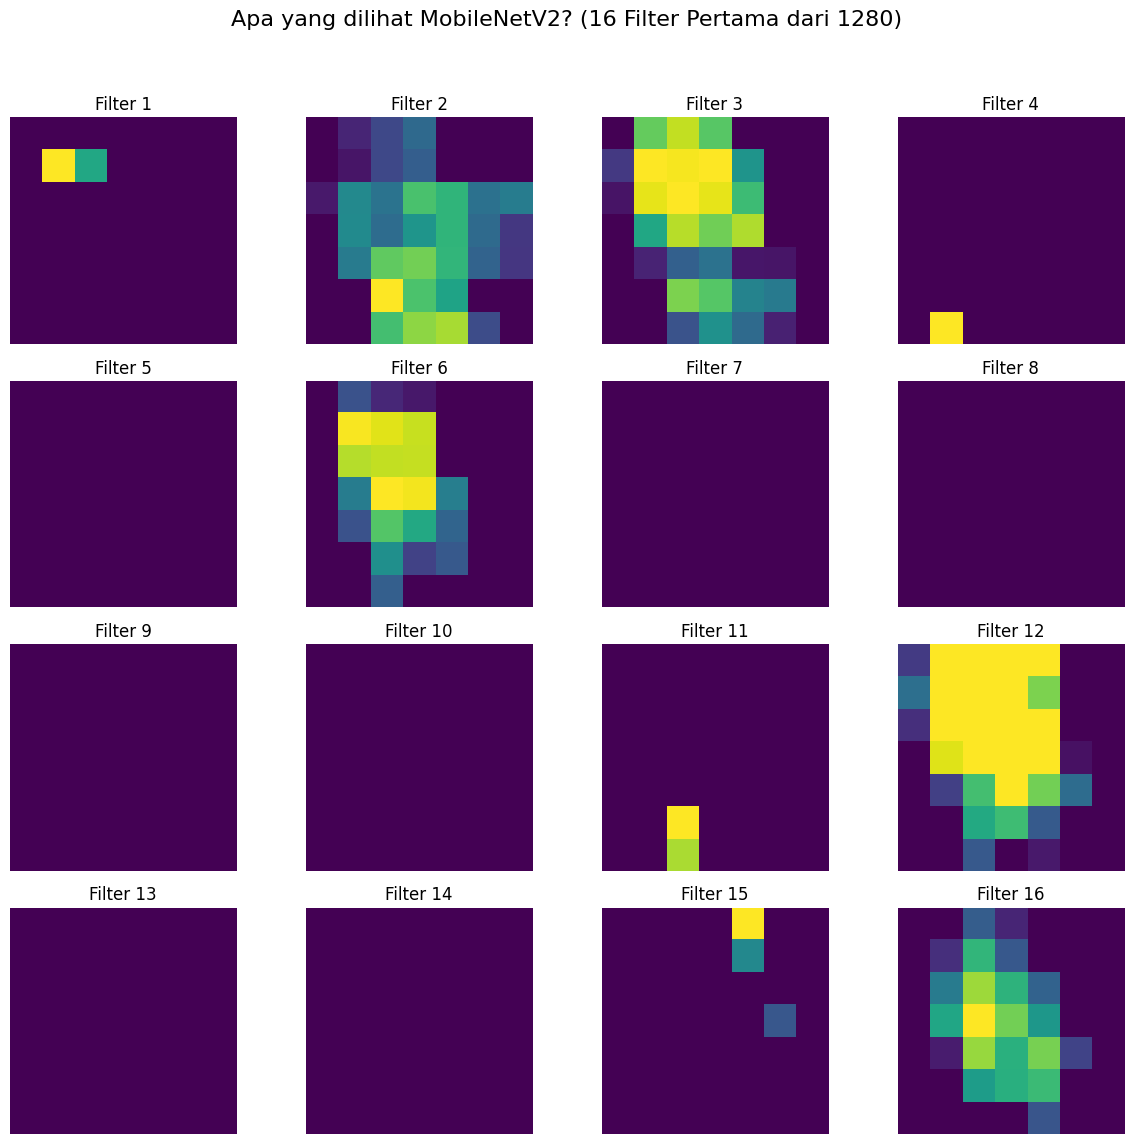


--- VISUALISASI HASIL POOLING (Bentuk: 1280) ---


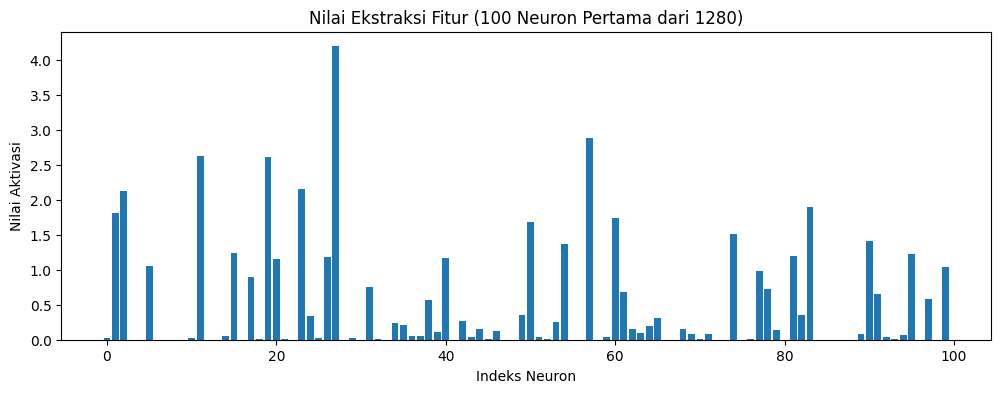

In [5]:
# --- VISUALISASI STEP 3: MEMBEDAH WARNA RGB ---
print("--- VISUALISASI KANAL WARNA RGB (Bentuk: 224, 224, 3) ---")
# Mengambil gambar dari batch (menghilangkan dimensi depan)
img_to_show = img_batch[0] / 255.0  # Normalisasi ke 0-1 untuk plot Matplotlib

plt.figure(figsize=(15, 4))
titles = ['Original (RGB)', 'Red Channel', 'Green Channel', 'Blue Channel']

# Plot RGB utuh
plt.subplot(1, 4, 1)
plt.imshow(img_to_show)
plt.title(titles[0])
plt.axis('off')

# Plot Red, Green, Blue secara terpisah
for i in range(3):
    plt.subplot(1, 4, i+2)
    # Membuat salinan gambar yang dikosongkan warna lainnya
    channel_img = np.zeros_like(img_to_show)
    channel_img[:, :, i] = img_to_show[:, :, i]
    plt.imshow(channel_img)
    plt.title(titles[i+1])
    plt.axis('off')

plt.tight_layout()
plt.show()

# --- VISUALISASI STEP 5: MELIHAT "PIKIRAN" AI (FEATURE MAPS) ---
print("\n--- VISUALISASI FEATURE MAPS (Bentuk: 7, 7, 1280) ---")
# Mengambil output fitur dari batch
feature_maps = features[0] 

# Kita tidak mungkin menampilkan 1280 gambar. 
# Kita akan ambil 16 "Filter" pertama saja sebagai contoh.
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i+1)
    # Menampilkan 1 filter spesifik (ukuran 7x7)
    plt.imshow(feature_maps[:, :, i], cmap='viridis')
    plt.title(f'Filter {i+1}')
    plt.axis('off')

plt.suptitle('Apa yang dilihat MobileNetV2? (16 Filter Pertama dari 1280)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- VISUALISASI STEP 6: ARRAY 1D SETELAH POOLING ---
print("\n--- VISUALISASI HASIL POOLING (Bentuk: 1280) ---")
# Menampilkan sebagian dari 1280 angka dalam bentuk grafik batang
plt.figure(figsize=(12, 4))
plt.bar(range(100), pooled_features[0][:100]) # Hanya menampilkan 100 nilai pertama agar tidak padat
plt.title('Nilai Ekstraksi Fitur (100 Neuron Pertama dari 1280)')
plt.xlabel('Indeks Neuron')
plt.ylabel('Nilai Aktivasi')
plt.show()